<a href="https://colab.research.google.com/github/hannahrachel30/Alignment-Bioinformatics/blob/main/Copy_of_ASEE0202Merge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import networkx as nx
import csv
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [6]:

def getp(c):
    file_path = 'grade.csv'
    data = pd.read_csv(file_path)
    total = data.loc[data['Unnamed: 0'] == c, 'Total'].iloc[0]
    d = data.loc[data['Unnamed: 0'] == c, 'D'].iloc[0]
    f = data.loc[data['Unnamed: 0'] == c, 'F'].iloc[0]
    n = data.loc[data['Unnamed: 0'] == c, 'N'].iloc[0]
    passed = total - d - f - n
    prob = passed / (total-n)
    return prob


def getcp(s,t):
    file_path = 'GGdag_edges.csv'
    data = pd.read_csv(file_path)
    w = data.loc[(data['source'] == s) & (data['target'] == t), 'w'].iloc[0]
    return w

def merge(G, nodes_to_merge, new_node):
    if new_node not in G:
        G.add_node(new_node)

    for node in nodes_to_merge:
      try:
        if node == new_node:
            continue
        for pred in list(G.predecessors(node)):
            G.add_edge(pred, new_node)
        for succ in list(G.successors(node)):
            G.add_edge(new_node, succ)
        G.remove_node(node)
      except:
        pass

def findPaths(G,u,n):
    if n==0:
        return [[u]]
    paths = [[u]+path for neighbor in G.neighbors(u) for path in findPaths(G,neighbor,n-1) if u not in path]
    return paths

getcp('MATH120','MATH125')

0.931

In [9]:
capstone = ['BIOL497','CHEM499','CS499','ECE405','ME484','MATH499','GEOG499','PHYS498','PHYS497','IE490','CE493','CNST470']

In [12]:
# Model1
fn = 'BIOL'
GGdag = nx.read_gml(fn+'R.gml')
JJ = GGdag.copy()
rn = []
mp = ['MATH120','MATH125','MATH145','MATH150','MATH152','MATH145','MATH250','MATH305']
merge(JJ, mp, 'MATH_P')
singletons = [node for node in JJ.nodes if (JJ.degree(node) == 0)]
JJ.remove_nodes_from(singletons)
JJ.remove_edges_from(nx.selfloop_edges(JJ))
source_nodes = [node for node in JJ.nodes if JJ.in_degree(node) == 0]

In [13]:
allpaths = []
for node in source_nodes:
    allpaths.extend(findPaths(JJ,node,2))
    allpaths.extend(findPaths(JJ,node,3))
    allpaths.extend(findPaths(JJ,node,4))
    allpaths.extend(findPaths(JJ,node,5))
    allpaths.extend(findPaths(JJ,node,6))
    allpaths.extend(findPaths(JJ,node,7))
    allpaths.extend(findPaths(JJ,node,8))
    allpaths.extend(findPaths(JJ,node,9))
    allpaths.extend(findPaths(JJ,node,10))
    allpaths.extend(findPaths(JJ,node,11))
    allpaths.extend(findPaths(JJ,node,12))
    allpaths.extend(findPaths(JJ,node,13))

print(len(allpaths))
p = []
for i in allpaths:
  if len(list(JJ.predecessors(i[0]))) == 0 and len(list(JJ.successors(i[-1]))) == 0 and i[-1] in capstone:
    p.append(i)

print("len->", len(p))

p = sorted(p,key=len, reverse=True)
for i in p:
  # print(f'{i} len{len(i)}')
  print(f'{i}')

497
len-> 8
['CHEM113', 'CHEM121A', 'BIOL150', 'BIOL151', 'BIOL220', 'BIOL492', 'BIOL497']
['CHEM113', 'CHEM121A', 'CHEM121B', 'CHEM125B', 'BIOL220', 'BIOL492', 'BIOL497']
['CHEM113', 'CHEM121A', 'CHEM121B', 'CHEM241A', 'BIOL220', 'BIOL492', 'BIOL497']
['CHEM113', 'CHEM121A', 'CHEM125A', 'BIOL151', 'BIOL220', 'BIOL492', 'BIOL497']
['MATH_P', 'CHEM121A', 'BIOL150', 'BIOL151', 'BIOL220', 'BIOL492', 'BIOL497']
['MATH_P', 'CHEM121A', 'CHEM121B', 'CHEM125B', 'BIOL220', 'BIOL492', 'BIOL497']
['MATH_P', 'CHEM121A', 'CHEM121B', 'CHEM241A', 'BIOL220', 'BIOL492', 'BIOL497']
['MATH_P', 'CHEM121A', 'CHEM125A', 'BIOL151', 'BIOL220', 'BIOL492', 'BIOL497']


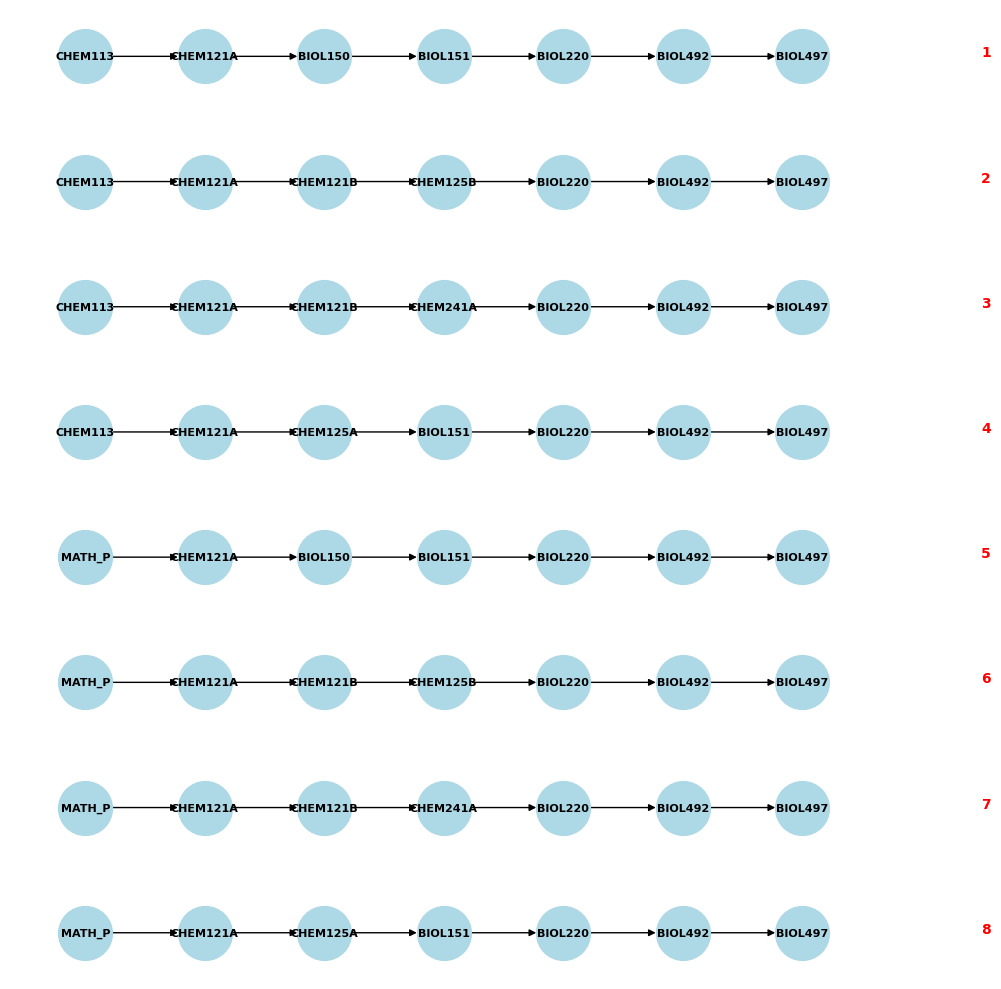

In [14]:
paths = p

max_x = max(len(path) for path in paths)

fig, ax = plt.subplots(figsize=(10, 10))
y_offset = 0

for i, path in enumerate(paths):
    G = nx.DiGraph()
    G.add_edges_from([(path[j], path[j + 1]) for j in range(len(path) - 1)])
    pos = {node: (idx, y_offset) for idx, node in enumerate(path)}
    y_offset -= 0.1
    nx.draw(
        G, pos, ax=ax, with_labels=True, node_size=1500, node_color='lightblue',
        font_size=8, font_weight='bold', arrowsize=10
    )
    ax.text(max_x + 0.5, y_offset + 0.1, f"{i + 1}", fontsize=10, color='red', fontweight='bold')

plt.axis("off")
plt.tight_layout()
plt.show()


In [15]:
# Model2
fn = 'CS'
GGdag = nx.read_gml(fn+'R.gml')
JJ = GGdag.copy()
rn = []
mp = ['MATH120','MATH125','MATH145','MATH150','MATH152','MATH145','MATH250','MATH305']
merge(JJ, mp, 'MATH_P')
singletons = [node for node in JJ.nodes if (JJ.degree(node) == 0)]
JJ.remove_nodes_from(singletons)
JJ.remove_edges_from(nx.selfloop_edges(JJ))
source_nodes = [node for node in JJ.nodes if JJ.in_degree(node) == 0]

In [16]:
allpaths = []
mpp = 0
for i in mp:
  mpp+=getp(i)
mpp/=len(mp)
for node in source_nodes:
    allpaths.extend(findPaths(JJ,node,2))
    allpaths.extend(findPaths(JJ,node,3))
    allpaths.extend(findPaths(JJ,node,4))
    allpaths.extend(findPaths(JJ,node,5))
    allpaths.extend(findPaths(JJ,node,6))
    allpaths.extend(findPaths(JJ,node,7))
    allpaths.extend(findPaths(JJ,node,8))
    allpaths.extend(findPaths(JJ,node,9))
    allpaths.extend(findPaths(JJ,node,10))
    allpaths.extend(findPaths(JJ,node,11))
    allpaths.extend(findPaths(JJ,node,12))
    allpaths.extend(findPaths(JJ,node,13))

print(len(allpaths))
p = {}
for i in allpaths:
  if len(list(JJ.predecessors(i[0]))) == 0 and len(list(JJ.successors(i[-1]))) == 0 and i[-1] in capstone:
    p[tuple(i)] = 1
print("len->", len(p))

for i,v in p.items():
  for j in i:
    if j =='MATH_P':
      v*=mpp
    else:
      v*=getp(j)
  p[i] = v
p = dict(sorted(p.items(), key=lambda x: x[1]))
for i,v in p.items():
  print(i,round(v,2))

78
len-> 10
('MATH_P', 'CS140', 'CS150', 'CS286', 'CS314', 'CS425', 'CS499') 0.42
('MATH_P', 'CS145', 'CS150', 'CS286', 'CS314', 'CS425', 'CS499') 0.43
('MATH_P', 'CS140', 'CS150', 'CS234', 'CS325', 'CS425', 'CS499') 0.6
('MATH_P', 'CS145', 'CS150', 'CS234', 'CS325', 'CS425', 'CS499') 0.6
('MATH_P', 'CS140', 'MATH224', 'CS340', 'CS425', 'CS499') 0.62
('MATH_P', 'CS140', 'CS150', 'CS340', 'CS425', 'CS499') 0.64
('MATH_P', 'CS145', 'CS150', 'CS340', 'CS425', 'CS499') 0.64
('MATH_P', 'CS340', 'CS425', 'CS499') 0.79
('CS111', 'CS234', 'CS325', 'CS425', 'CS499') 0.8
('CS360', 'CS425', 'CS499') 0.97


In [ ]:
getp('ECE365')

0.9598214285714286

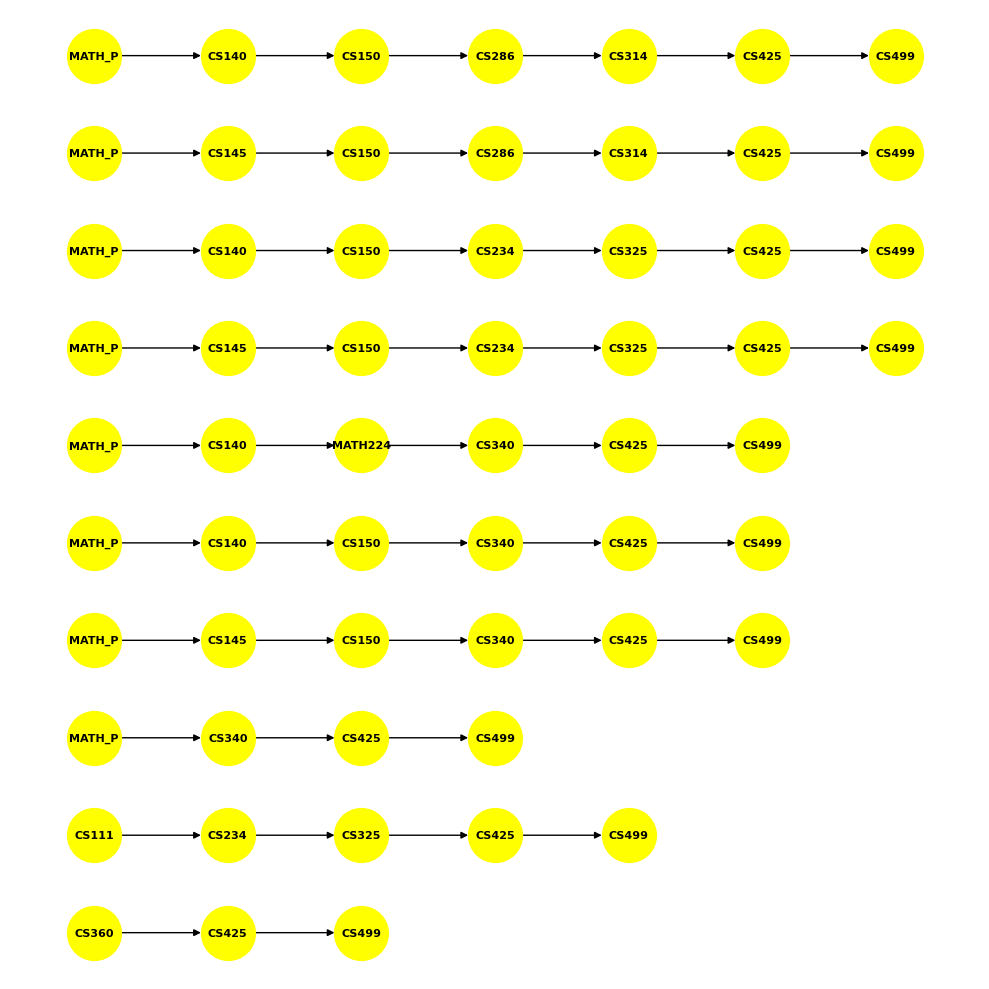

In [17]:
paths = p
fig, ax = plt.subplots(figsize=(10, 10))
y_offset = 0

for i, path in enumerate(paths):
    G = nx.DiGraph()
    G.add_edges_from([(path[j], path[j + 1]) for j in range(len(path) - 1)])
    pos = {node: (idx, y_offset) for idx, node in enumerate(path)}
    y_offset -= 0.1
    nx.draw(
        G, pos, ax=ax, with_labels=True, node_size=1500, node_color='yellow',
        font_size=8, font_weight='bold', arrowsize=10
    )
plt.axis("off")
plt.tight_layout()
plt.show()


0.8916446790403058

In [92]:
# Model3
fn = 'ME'
GGdag = nx.read_gml(fn+'R.gml')
JJ = GGdag.copy()
mp = ['MATH120','MATH125','MATH145','MATH150','MATH152','MATH250','MATH305']
merge(JJ, mp, 'MATH_P')
singletons = [node for node in JJ.nodes if (JJ.degree(node) == 0)]
JJ.remove_nodes_from(singletons)
JJ.remove_edges_from(nx.selfloop_edges(JJ))
source_nodes = [node for node in JJ.nodes if JJ.in_degree(node) == 0]

In [93]:
# JJ = GGdag.copy()
allpaths = []
for node in source_nodes:
    allpaths.extend(findPaths(JJ,node,2))
    allpaths.extend(findPaths(JJ,node,3))
    allpaths.extend(findPaths(JJ,node,4))
    allpaths.extend(findPaths(JJ,node,5))
    allpaths.extend(findPaths(JJ,node,6))
    allpaths.extend(findPaths(JJ,node,7))
    allpaths.extend(findPaths(JJ,node,8))
    allpaths.extend(findPaths(JJ,node,9))
    allpaths.extend(findPaths(JJ,node,10))
    allpaths.extend(findPaths(JJ,node,11))
    allpaths.extend(findPaths(JJ,node,12))
    allpaths.extend(findPaths(JJ,node,13))

print(len(allpaths))
p = {}
for i in allpaths:
  if len(list(JJ.predecessors(i[0]))) == 0 and len(list(JJ.successors(i[-1]))) == 0 and i[-1] in capstone:
    p[tuple(i)] = 1
print("len->", len(p))






193
len-> 11


In [85]:
for i,v in p.items():
  for j in range(len(i) - 1):
    s = i[j]
    t = i[j+1]

    if s =='MATH_P':
      file = 'GGdag_edges.csv'
      data = pd.read_csv(file)
      n=0
      d=0
      w=0
      for m in mp:
        if ((data['source'] == m) & (data['target'] == t)).any():
          d += data.loc[(data['source'] == m) & (data['target'] == t), 'd'].iloc[0]
          n += data.loc[(data['source'] == m) & (data['target'] == t), 'n'].iloc[0]
      if n!=0 and d!=0:
        w = n/d
    v*=w
  else:
    v*=getcp(s,t)


if i[0] =="MATH_P":
  v*=mpp
else:
  v*=getp(i[0])

p[i] = v
p = dict(sorted(p.items(), key=lambda x: x[1]))
for i,v in p.items():
  print(i,v)

#     v*=getcp(s,t)
#   v*=getp(i[0])
#   p[i] = v

# p = dict(sorted(p.items(), key=lambda x: x[1]))
# for i,v in p.items():
#   print(i,v)

('MATH_P', 'PHYS140', 'PHYS141', 'CE240', 'CE242', 'ME380', 'ME482', 'ME484') 0.38171099909922085
('MATH_P', 'ME354', 'ME350', 'ME482', 'ME484') 1
('MATH_P', 'ME354', 'ME380', 'ME482', 'ME484') 1
('MATH_P', 'PHYS141', 'CE240', 'ME262', 'ME350', 'ME482', 'ME484') 1
('MATH_P', 'PHYS141', 'CE240', 'CE242', 'ME370', 'ME482', 'ME484') 1
('MATH_P', 'PHYS141', 'CE240', 'CE242', 'ME380', 'ME482', 'ME484') 1
('MATH_P', 'PHYS151', 'CE240', 'ME262', 'ME350', 'ME482', 'ME484') 1
('MATH_P', 'PHYS151', 'CE240', 'CE242', 'ME370', 'ME482', 'ME484') 1
('MATH_P', 'PHYS151', 'CE240', 'CE242', 'ME380', 'ME482', 'ME484') 1
('MATH_P', 'PHYS140', 'PHYS141', 'CE240', 'ME262', 'ME350', 'ME482', 'ME484') 1
('MATH_P', 'PHYS140', 'PHYS141', 'CE240', 'CE242', 'ME370', 'ME482', 'ME484') 1


In [94]:
# p = {('MATH_P', 'PHYS140', 'PHYS141', 'CE240', 'CE242', 'ME380', 'ME482', 'ME484'):1}
for i,v in p.items():
  for j in range(len(i) - 1):
    s = i[j]
    t = i[j+1]
    if s =='MATH_P':
      file = 'GGdag_edges.csv'
      data = pd.read_csv(file)
      # print(s,t)
      n,d = 0,0
      for m in mp:

        try:
          # print(m)
          # print("d",data.loc[(data['source'] == m) & (data['target'] == t), 'd'].iloc[0])
          # print("n",data.loc[(data['source'] == m) & (data['target'] == t), 'n'].iloc[0])
          d += data.loc[(data['source'] == m) & (data['target'] == t), 'd'].iloc[0]

          n += data.loc[(data['source'] == m) & (data['target'] == t), 'n'].iloc[0]
        except:
          pass


      if n!= 0 and d!= 0: w = n/d
      v*=w

    else:
      v*=getcp(s,t)

    p[i] = v



if i[0] =="MATH_P":
  v*=mpp
else:
  v*=getp(i[0])

# p[i] = v
p = dict(sorted(p.items(), key=lambda x: x[1],reverse = True))
for i,v in p.items():
  print(i,v)

# #     v*=getcp(s,t)
# #   v*=getp(i[0])
# #   p[i] = v

# # p = dict(sorted(p.items(), key=lambda x: x[1]))
# # for i,v in p.items():
# #   print(i,v)

('MATH_P', 'ME354', 'ME350', 'ME482', 'ME484') 0.9199705387032419
('MATH_P', 'ME354', 'ME380', 'ME482', 'ME484') 0.9083007221446384
('MATH_P', 'PHYS141', 'CE240', 'CE242', 'ME370', 'ME482', 'ME484') 0.7908377541389623
('MATH_P', 'PHYS141', 'CE240', 'ME262', 'ME350', 'ME482', 'ME484') 0.7892319271507666
('MATH_P', 'PHYS151', 'CE240', 'CE242', 'ME370', 'ME482', 'ME484') 0.7791746261908765
('MATH_P', 'PHYS151', 'CE240', 'ME262', 'ME350', 'ME482', 'ME484') 0.7775924816401059
('MATH_P', 'PHYS141', 'CE240', 'CE242', 'ME380', 'ME482', 'ME484') 0.7590050097160131
('MATH_P', 'PHYS151', 'CE240', 'CE242', 'ME380', 'ME482', 'ME484') 0.7478113451555826
('MATH_P', 'PHYS140', 'PHYS141', 'CE240', 'CE242', 'ME370', 'ME482', 'ME484') 0.7052175523023625
('MATH_P', 'PHYS140', 'PHYS141', 'CE240', 'ME262', 'ME350', 'ME482', 'ME484') 0.7037855804824671
('MATH_P', 'PHYS140', 'PHYS141', 'CE240', 'CE242', 'ME380', 'ME482', 'ME484') 0.6768311860881437


In [ ]:
# paths = p
# fig, ax = plt.subplots(figsize=(10, 10))  # 调整画布大小
# y_offset = 0

# for i, path in enumerate(paths):
#     G = nx.DiGraph()
#     G.add_edges_from([(path[j], path[j + 1]) for j in range(len(path) - 1)])
#     pos = {node: (idx, y_offset) for idx, node in enumerate(path)}
#     y_offset -= 0.1
#     nx.draw(
#         G, pos, ax=ax, with_labels=True, node_size=1500, node_color='mediumpurple',
#         font_size=8, font_weight='bold', arrowsize=10
#     )
#     ax.text(max_x + 0.5, y_offset + 0.1, f"{paths[key]}", fontsize=10, color='red', fontweight='bold')
# plt.axis("off")
# plt.tight_layout()
# plt.show()


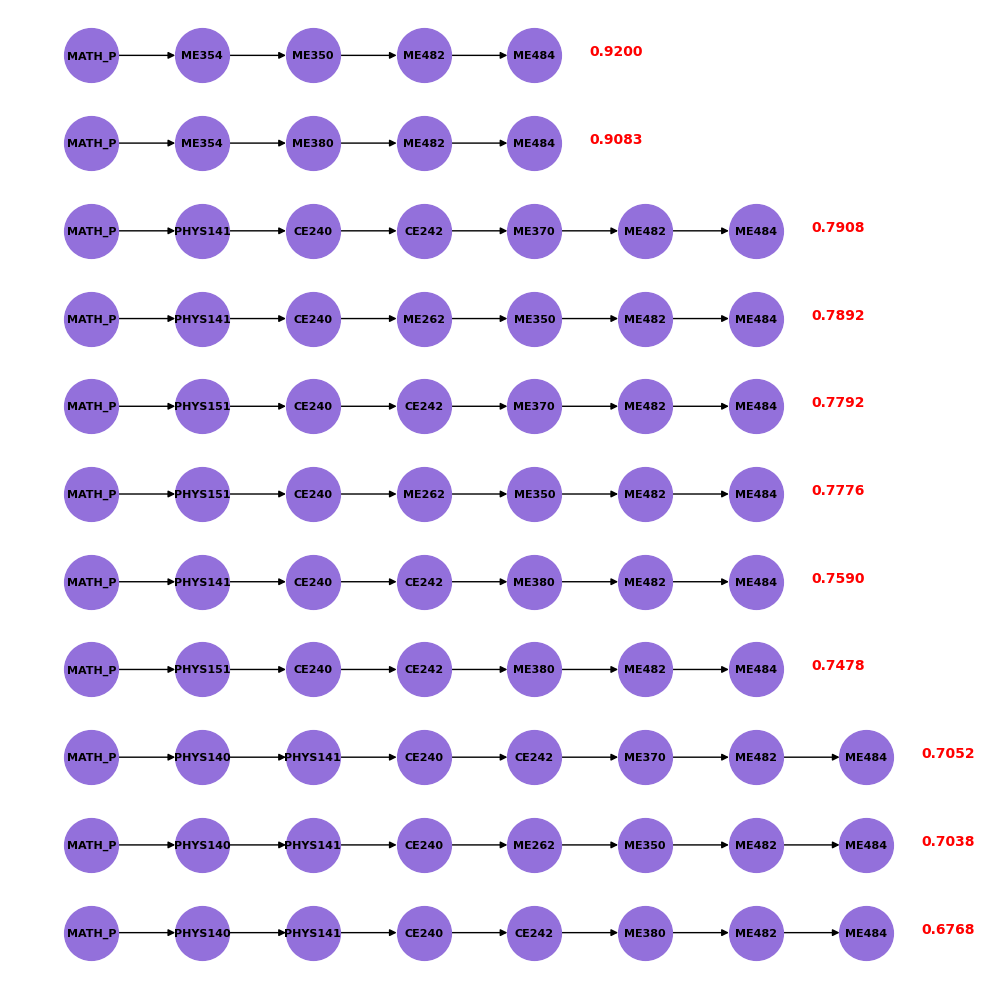

In [95]:
import networkx as nx
import matplotlib.pyplot as plt

# p = {('MATH_P', 'PHYS140', 'PHYS141', 'CE240', 'CE242', 'ME380', 'ME482', 'ME484'): 0.6768311860881437}
paths = p

fig, ax = plt.subplots(figsize=(10, 10))  # Adjust figure size
y_offset = 0

for i, (path, score) in enumerate(paths.items()):  # Extract key-value pairs
    G = nx.DiGraph()
    G.add_edges_from([(path[j], path[j + 1]) for j in range(len(path) - 1)])

    pos = {node: (idx, y_offset) for idx, node in enumerate(path)}
    max_x = max(pos[node][0] for node in pos)  # Determine the max X position
    y_offset -= 0.1  # Shift Y position for the next path

    nx.draw(
        G, pos, ax=ax, with_labels=True, node_size=1500, node_color='mediumpurple',
        font_size=8, font_weight='bold', arrowsize=10
    )

    # Display the score (value of p) near the path
    ax.text(max_x + 0.5, y_offset + 0.1, f"{score:.4f}", fontsize=10, color='red', fontweight='bold')

plt.axis("off")
plt.tight_layout()
plt.show()
